# T14 — Paleo-strain rate maps

**A pyGMT port of the upstream pyGPlates tutorial [`pygplates-plate-boundary-convergence-and-deforming-region-strain-rates.ipynb`](https://github.com/GPlates/pygplates-tutorials/blob/master/notebooks/pygplates-plate-boundary-convergence-and-deforming-region-strain-rates.ipynb).**

We use pygplates' `TopologicalModel` directly to compute two complementary diagnostics of plate-tectonic activity at any reconstruction time:

1. **Plate-boundary convergence / divergence velocity.** Sampled every 2° along every resolved boundary. Positive = convergent (subduction, collision); negative = divergent (mid-ocean ridge, rift). We render these as colored circles using a diverging red–blue colormap.

2. **Deforming-region dilatation rate.** For each `gpml:TopologicalNetwork` (the deforming meshes embedded in the topology — extending margins, orogens, back-arcs), pygplates returns a Delaunay triangulation of the network interior with a strain-rate tensor at every vertex. The first invariant (dilatation rate, in s⁻¹) is positive in stretched crust and negative in shortened crust. We interpolate vertex values onto a regular grid via `matplotlib.tri.LinearTriInterpolator` and render via pyGMT's `grdimage`.

Together these two layers give a quantitative picture of *where* plates are moving toward or away from each other (boundary stats) and *where* the associated crustal deformation is concentrated (network strain).

## What you will learn

- How to drive pygplates' `TopologicalModel` and `TopologicalSnapshot` API.
- How to extract boundary-statistic point samples (uniform 2° spacing).
- How to walk a deforming network's Delaunay triangulation and sample strain rates at every vertex.
- How to interpolate a vertex-based scalar field onto an `xarray.DataArray` and feed it to `fig.grdimage` for publication-quality pyGMT rendering.
- The relationship between *kinematic* (boundary velocity) and *deformational* (network strain) measures of plate activity.

**Audience**: postgraduate.  
**Difficulty**: ★★★.  
**Prerequisites**: GPlately + pyGMT, plus `matplotlib` (for the triangulation helper). Internet for `plate_model_manager` to fetch Zahirovic2022 on first run.  
**Runtime**: ≈30–60 s per snapshot.

In [1]:
# Cell 1 — imports and version check
import numpy as np
import xarray as xr
import matplotlib.tri as mtri
import gplately
import pygplates
import pygmt
from plate_model_manager import PlateModelManager
from IPython.display import display, HTML

print(f'gplately   {gplately.__version__}')

# Suite-wide tutorial style: bigger panel titles, 1cm gap between figures.
pygmt.config(FONT_TITLE="18p", FONT_LABEL="18p",
             FONT_ANNOT_PRIMARY="14p")
print(f'pygplates  {pygplates.__version__}')
print(f'pygmt      {pygmt.__version__}')

gplately   2.0.0.post19+git.2cce7bb3
pygplates  1.0.0
pygmt      v0.18.0


## 1. Load the Zahirovic 2022 plate model — anchored on Eurasia

We load Zahirovic et al. (2022) via `plate_model_manager`. We need three things from the model:

- a `gplately.PlateReconstruction` (rotation model + topologies + static polygons),
- a `gplately.PlotTopologies` so that we can pull coastlines, ridges, transforms and subduction zones for any reconstruction time, and
- a `pygplates.TopologicalModel` for the boundary-statistic and deforming-network calculations. `TopologicalModel` is the pygplates primitive that resolves the model's topology at a given time and exposes low-level access to the Delaunay-mesh strain-rate and per-vertex velocity data; GPlately's `PlotTopologies` wraps it for plotting but doesn't expose the strain rates or velocities directly.

**Reference frame.** We explicitly anchor the rotation model on plate **ID 301 (Eurasia)** in the EarthByte / Zahirovic2022 convention. The default anchor (plate 0) is the absolute mantle / moving-hotspot reference frame, in which India's velocity at 20 Ma reads as ≈10 cm/yr north-north-east — its hotspot-frame absolute motion. We are more interested in *how blocks move relative to each other* — the India–Asia convergence rate, Tibetan east–west extension, Sundaland lateral escape — and these read most cleanly when Eurasia is held still. Two physical fields are unaffected by the choice of anchor:

1. The **dilatation-rate field** inside each deforming network — it is the divergence of the velocity field, so any rigid translation drops out.
2. The **convergence / divergence velocity** along plate boundaries — this is the *relative* velocity between the two adjoining plates, so it is anchor-invariant.

Only the absolute velocity arrows at the deforming-mesh vertices change with the anchor choice.

In [2]:
# Cell 2 — Zahirovic 2022 plate model + TopologicalModel
#
# We anchor on plate ID 301 (Eurasia in the EarthByte / Zahirovic2022
# convention) so the deforming-mesh velocity arrows show motion
# *relative to stable Eurasia* — India's collision, Tibetan east-west
# extension, and Sundaland escape then read at their tectonically
# meaningful relative rates rather than at the hotspot-frame absolute
# rates of the default anchor (plate 0). The dilatation-rate field and
# the convergence/divergence values at boundaries are reference-frame
# *invariant*, so only the velocity arrows are affected by this choice.
ANCHOR_PLATE_ID = 301   # Eurasia

pmm = PlateModelManager()
model = pmm.get_model('Zahirovic2022', data_dir='./gplately_data')

# Wrap the raw rotation model with a Eurasia-anchored default. Passing
# this wrapped object to BOTH gplately and pygplates ensures the topology
# rendering, boundary stats and velocity arrows are all in the same frame.
rotation_model = pygplates.RotationModel(
    model.get_rotation_model(),
    default_anchor_plate_id=ANCHOR_PLATE_ID,
)
topology_features = model.get_topologies()
static_polygons   = model.get_static_polygons()

recon = gplately.PlateReconstruction(rotation_model,
                                     topology_features,
                                     static_polygons)
gplot = gplately.PlotTopologies(plate_reconstruction=recon,
                                coastlines=model.get_coastlines(),
                                continents=model.get_continental_polygons(),
                                COBs=model.get_COBs(),
                                time=0)

# pygplates.TopologicalModel is the strain-rate-aware engine. The
# topological_snapshot(t) method resolves topologies at time t and lets us
# query both boundary statistics and network strain rates / velocities.
topological_model = pygplates.TopologicalModel(
    topology_features, rotation_model,
    anchor_plate_id=ANCHOR_PLATE_ID,
)

print('Model loaded:')
print(f'  anchor plate     : {ANCHOR_PLATE_ID} (Eurasia)')
print(f'  rotation features: present')
print(f'  topology features: present')
print(f'  static polygons  : present')

Model loaded:
  anchor plate     : 301 (Eurasia)
  rotation features: present
  topology features: present
  static polygons  : present


## 2. Convergence / divergence velocities along plate boundaries

The pygplates method `topological_snapshot.calculate_plate_boundary_statistics()` samples *every* resolved plate boundary at a uniform spacing (we use 2°) and returns a list of `PlateBoundaryStatistic` objects. Each statistic carries:

- the boundary `boundary_point` (a `pygplates.PointOnSphere`),
- the left- and right-plate IDs,
- the convergence velocity as a 3-D `Vector3D`, and
- `convergence_velocity_signed_magnitude` (positive = convergent, negative = divergent).

We extract `(lon, lat, signed_magnitude_cm_per_yr)` for each point and keep the ones inside our map region. The signed magnitude is what we color the circles by — no arrows, just point markers on a diverging colormap.

In [3]:
# Cell 3 — helper: boundary convergence statistics
def calculate_convergence_stats(topological_snapshot, region=None,
                                spacing_deg=2.0):
    '''Return (lons, lats, signed_mag_cm_per_yr) for every uniformly-sampled
    plate-boundary point, optionally clipped to (W, E, S, N).'''
    stats = topological_snapshot.calculate_plate_boundary_statistics(
        np.radians(spacing_deg),
        first_uniform_point_spacing_radians=0.0,
        velocity_units=pygplates.VelocityUnits.cms_per_yr,
    )
    # Keep only the points that actually have a convergence velocity.
    stats = [s for s in stats if s.convergence_velocity]

    lons       = np.empty(len(stats))
    lats       = np.empty(len(stats))
    signed_mag = np.empty(len(stats))
    for i, s in enumerate(stats):
        lat, lon = s.boundary_point.to_lat_lon()
        lons[i]       = lon
        lats[i]       = lat
        signed_mag[i] = s.convergence_velocity_signed_magnitude

    if region is not None:
        W, E, S, N = region
        m = (lons >= W) & (lons <= E) & (lats >= S) & (lats <= N)
        lons, lats, signed_mag = lons[m], lats[m], signed_mag[m]

    return lons, lats, signed_mag

## 3. Deforming-region dilatation rate from the network triangulation

Each `gpml:TopologicalNetwork` exposes a Delaunay-mesh triangulation. Every vertex carries a full strain-rate tensor; the *dilatation rate* (the first invariant of the rate-of-strain tensor — positive = expanding area, negative = shortening area) is what we display. Values are tiny in absolute terms (∼10⁻¹⁷ s⁻¹), so we multiply by 10¹⁷ to get readable numbers in the plot.

The upstream pyGPlates notebook recursively subdivides each triangle until edges are ≤0.5° on the sphere, then renders the subdivided mesh via matplotlib's `tripcolor`. For a pyGMT-friendly rendering we instead interpolate the vertex values onto a regular `xarray.DataArray` grid via `matplotlib.tri.LinearTriInterpolator` — the grid passes straight to `fig.grdimage`, which is the canonical pyGMT primitive for scalar fields. Grid points outside any deforming triangle remain `NaN` and render transparent.

In [4]:
# Cell 4 — helper: vertex-based dilatation rate -> regular grid
def _vertices_and_triangles(resolved_network):
    '''Pull (vertex_lons, vertex_lats, vertex_dilatation_rates, triangle_indices)
    from one resolved deforming network. Only triangles inside the deforming
    region are returned (the network can include rigid "holes").'''
    netri = resolved_network.get_network_triangulation()
    verts = netri.get_vertices()
    vlons = np.empty(len(verts))
    vlats = np.empty(len(verts))
    vdr   = np.empty(len(verts))
    vidx  = {}
    for i, v in enumerate(verts):
        lat, lon = v.position.to_lat_lon()
        vlons[i] = lon
        vlats[i] = lat
        vdr[i]   = v.strain_rate.get_dilatation_rate()
        vidx[v]  = i
    tris = []
    for tri in netri.get_triangles():
        if tri.is_in_deforming_region:
            tris.append([vidx[tri.get_vertex(j)] for j in (0, 1, 2)])
    return vlons, vlats, vdr, np.asarray(tris, dtype=int)


def make_dilatation_grid(topological_snapshot, region, spacing=0.2, smooth_sigma_deg=1.0):
    """Combine every deforming network in the snapshot into one regular grid
    covering `region` = (W, E, S, N). Returns an xarray.DataArray of
    dilatation rate scaled to units of 10**-17 s**-1. NaN outside any
    deforming triangle.

    Robustness notes:
      - We drop degenerate triangles (duplicate vertex indices or zero
        2-D cross-product) before handing them to matplotlib.
      - We reindex remaining triangles to a compact 0..N-1 vertex array
        so the trifinder doesn't see orphan vertices.
      - We catch RuntimeError per network — one bad mesh skips with a
        warning instead of killing the whole frame.
    """
    W, E, S, N = region
    lon_axis = np.arange(W, E + spacing, spacing)
    lat_axis = np.arange(S, N + spacing, spacing)
    LON, LAT = np.meshgrid(lon_axis, lat_axis)
    field    = np.full(LON.shape, np.nan)

    networks = topological_snapshot.get_resolved_topologies(
        pygplates.ResolveTopologyType.network)
    for inet, net in enumerate(networks):
        vlons, vlats, vdr, tris = _vertices_and_triangles(net)
        if len(tris) == 0:
            continue

        # 0) Skip dateline-crossing networks. matplotlib triangulation is
        # 2-D Euclidean in (lon, lat); a network whose vertices straddle
        # lon = +/- 180 produces triangles that span the whole globe in 2-D
        # and the trifinder rejects them. Such networks (e.g. Tonga, the
        # northwest-Pacific arcs) almost never sit inside the user's region
        # of interest anyway, so we skip with a clear note.
        if vlons.max() - vlons.min() > 180.0:
            print(f'  (skipping network #{inet}: spans the dateline — '
                  f'matplotlib triangulation cannot represent it in 2-D)')
            continue

        # 1) Drop degenerate triangles.
        good = []
        for tri in tris:
            if len(set(tri)) < 3:
                continue
            ax, ay = vlons[tri[0]], vlats[tri[0]]
            bx, by = vlons[tri[1]], vlats[tri[1]]
            cx, cy = vlons[tri[2]], vlats[tri[2]]
            cross = (bx - ax) * (cy - ay) - (by - ay) * (cx - ax)
            if abs(cross) < 1e-9:
                continue
            good.append(tri)
        if not good:
            continue
        good = np.asarray(good, dtype=int)

        # 2) Reindex to compact vertex array.
        used = np.unique(good.ravel())
        remap = -np.ones(len(vlons), dtype=int)
        remap[used] = np.arange(len(used))
        good = remap[good]
        sub_vlons = vlons[used]
        sub_vlats = vlats[used]
        sub_vdr   = vdr[used]

        # 3) Interpolate, guarded by try/except.
        try:
            triangulation = mtri.Triangulation(sub_vlons, sub_vlats, good)
            interp = mtri.LinearTriInterpolator(triangulation, sub_vdr)
            z = interp(LON, LAT)
        except RuntimeError as exc:
            print(f'  (skipping network #{inet}: {exc})')
            continue

        if hasattr(z, 'mask'):
            valid = ~z.mask & np.isnan(field)
            field = np.where(valid, z.data, field)
        else:
            valid = ~np.isnan(z) & np.isnan(field)
            field = np.where(valid, z, field)

    # Post-smooth with a NaN-aware Gaussian. Without the mask-weight
    # trick, gaussian_filter would bleed NaN three sigmas outward and
    # erode the deforming-region boundary.
    if smooth_sigma_deg is not None and smooth_sigma_deg > 0:
        import scipy.ndimage as _ndi
        sigma_pix = smooth_sigma_deg / spacing
        mask = ~np.isnan(field)
        filled = np.where(mask, field, 0.0)
        smoothed = _ndi.gaussian_filter(filled, sigma=sigma_pix)
        weight = _ndi.gaussian_filter(mask.astype(float), sigma=sigma_pix)
        with np.errstate(invalid='ignore', divide='ignore'):
            smoothed = np.where(weight > 1e-6, smoothed / weight, np.nan)
        # Restore the original deforming-region mask so we don't paint
        # smoothed values over rigid plates.
        field = np.where(mask, smoothed, np.nan)

    return xr.DataArray(field * 1e17,
                        dims=('lat', 'lon'),
                        coords={'lat': lat_axis, 'lon': lon_axis},
                        name='dilatation_rate_1e-17_per_s')

In [5]:
# Cell 4b — helper: per-vertex velocities for every deforming network
def calculate_network_vertex_velocities(topological_snapshot, region=None,
                                        subsample_cell_deg=2.5):
    '''Return (lons, lats, east_cm_per_yr, north_cm_per_yr) at every vertex
    of every deforming network's Delaunay triangulation. Velocity comes
    from `vertex.get_velocity(velocity_units=cms_per_yr)` — pygplates
    bakes in both the rigid block motion AND the intra-network deformation
    contribution, so the arrows on the map show how the blocks really
    move in the reconstruction's anchor frame.

    Vertices are spatially thinned to at most one arrow per
    `subsample_cell_deg` x `subsample_cell_deg` cell so the map isn't a
    thicket of arrows where the Delaunay mesh is dense.'''
    networks = topological_snapshot.get_resolved_topologies(
        pygplates.ResolveTopologyType.network)

    all_positions  = []
    all_velocities = []
    for net in networks:
        triangulation = net.get_network_triangulation()
        for vertex in triangulation.get_vertices():
            all_positions.append(vertex.position)
            all_velocities.append(vertex.get_velocity(
                velocity_units=pygplates.VelocityUnits.cms_per_yr))

    if not all_positions:
        z = np.empty(0)
        return z, z, z, z

    # Project geocentric Vector3D velocities to local North-East-Down so
    # we can recover the (east, north) components.
    ned = pygplates.LocalCartesian.convert_from_geocentric_to_north_east_down(
        all_positions, all_velocities)

    lons  = np.empty(len(all_positions))
    lats  = np.empty(len(all_positions))
    east  = np.empty(len(all_positions))
    north = np.empty(len(all_positions))
    for i, pt in enumerate(all_positions):
        lat, lon = pt.to_lat_lon()
        lons[i]  = lon
        lats[i]  = lat
        east[i]  = ned[i].get_y()
        north[i] = ned[i].get_x()

    # Spatial thinning — keep one arrow per coarse cell
    seen = set()
    keep = []
    for i in range(len(lons)):
        cell = (int(np.floor(lats[i] / subsample_cell_deg)),
                int(np.floor(lons[i] / subsample_cell_deg)))
        if cell not in seen:
            seen.add(cell)
            keep.append(i)
    keep = np.asarray(keep, dtype=int)
    lons, lats, east, north = lons[keep], lats[keep], east[keep], north[keep]

    if region is not None:
        W, E, S, N = region
        m = (lons >= W) & (lons <= E) & (lats >= S) & (lats <= N)
        lons, lats, east, north = lons[m], lats[m], east[m], north[m]
    return lons, lats, east, north


# Cell 4c — helper: plate-motion velocities on a regular grid across the
# whole region, using the topological snapshot directly via pygplates
# (same API pattern as calculate_network_vertex_velocities above so we
# know the units and conventions match). Works for rigid plate interiors
# AND deforming networks — the snapshot resolves which topology contains
# each sample point and returns the local velocity.
def calculate_plate_motion_arrows(topological_snapshot, region,
                                  spacing_deg=1.5):
    '''Return (lons, lats, east_cm_per_yr, north_cm_per_yr) sampled on a
    regular lat/lon grid across `region` = (W, E, S, N). Velocities are
    in cm/yr in the snapshot's anchor frame.'''
    W, E, S, N = region
    lon_arr = np.arange(W + spacing_deg / 2, E, spacing_deg)
    lat_arr = np.arange(S + spacing_deg / 2, N, spacing_deg)
    glon, glat = np.meshgrid(lon_arr, lat_arr)
    flat_lons = glon.flatten()
    flat_lats = glat.flatten()
    points = [pygplates.PointOnSphere(lat, lon)
              for lat, lon in zip(flat_lats, flat_lons)]

    velocities = topological_snapshot.get_point_velocities(
        points,
        velocity_delta_time=1.0,
        velocity_units=pygplates.VelocityUnits.cms_per_yr,
    )

    # Some points may fall outside any resolved topology (rare, but happens
    # at small gaps); skip those.
    keep = [i for i, v in enumerate(velocities) if v is not None]
    if not keep:
        z = np.empty(0)
        return z, z, z, z

    pts_valid = [points[i] for i in keep]
    vecs_valid = [velocities[i] for i in keep]
    ned = pygplates.LocalCartesian.convert_from_geocentric_to_north_east_down(
        pts_valid, vecs_valid)

    lons = np.array([flat_lons[i] for i in keep])
    lats = np.array([flat_lats[i] for i in keep])
    east = np.array([n.get_y() for n in ned])
    north = np.array([n.get_x() for n in ned])
    return lons, lats, east, north

## 4. Render with pyGMT

Following suite house style we render each time slice as its own `pygmt.Figure` — no `pygmt.subplot` (we have multiple layers with their own colormaps; subplot's uniform-cell constraint would force compromises). Each figure layers, in draw order:

1. Land + coastlines (light grey)
2. **Dilatation-rate grid** via `fig.grdimage` (diverging `polar` cpt, SymLog scaling clipped at ±5 × 10⁻¹⁷ s⁻¹)
3. Continuous topology backbone (grey) + ridges (red) + subduction teeth (black)
4. **Deforming-mesh velocity arrows** — one black arrow per ≈2.5° cell at vertices of every deforming network, length linearly proportional to absolute velocity magnitude (cm/yr). These show how the blocks inside each topological network are moving in the reconstruction's anchor frame.
5. **Convergence velocity points** as colored circles (diverging `polar` cpt, linear scale clipped at ±10 cm/yr)
6. Two stacked colorbars at the bottom.

### What the three snapshots show

Each frame layers three independent fields:

- **Dilatation-rate colour grid** inside the deforming-mesh networks. Red = extension (areas growing); blue = shortening. The colour scale is SymLog clipped at ±5 × 10⁻¹⁷ s⁻¹. India–Asia collision lights up blue (shortening); Tibet and Sundaland light up red (extension/escape).
- **Black velocity arrows** at every Delaunay-mesh vertex inside the deforming networks, in the **Eurasia-fixed** reference frame. Arrow length is proportional to absolute velocity magnitude.
- **Colored circles** at every uniformly-sampled plate-boundary point, with the colour scale encoding signed convergence velocity (red = convergent, blue = divergent). These are reference-frame-invariant.

Compare 40 Ma → 20 Ma → 0 Ma to watch India ploughing north into Asia and the Sundaland block escaping eastward.

In [6]:
# Cell 5 — render one snapshot
def render_snapshot(t, region, fig_width=720, vel_scale=0.10,
                    vel_min_cm_per_yr=0.5):
    '''Render plate-boundary convergence + deforming-region dilatation for
    time `t` over map `region` = (W, E, S, N).'''
    snap = topological_model.topological_snapshot(t)
    grid = make_dilatation_grid(snap, region, spacing=0.2)
    blons, blats, bmag = calculate_convergence_stats(snap, region=region)

    gplot.time = t
    engine = gplately.PygmtPlotEngine()

    fig = pygmt.Figure()
    fig.basemap(region=list(region), projection='M16c',
                frame=['af',
                       f'+tPlate convergence + deforming-region dilatation at {t} Ma'])
    # Light grey land for context
    fig.coast(land='gray90', shorelines='0.2p,gray40', resolution='l')

    # Dilatation rate grid (diverging cpt, SymLog scaling)
    pygmt.makecpt(cmap='polar', series=[-5, 5, 0.1], background=True)
    if grid.notnull().any():
        fig.grdimage(grid, cmap=True, nan_transparent=True, transparency=20)
    fig.colorbar(frame='af+lDilatation rate (10@+-17@+ s@+-1@+)',
                 position='JBC+w11c/0.3c+h+o0/1.5c')

    # Continuous topology backbone first, then styled layers on top.
    engine.plot_geo_data_frame(fig, gplot.get_all_topological_sections(),
                               pen='0.5p,gray40')
    engine.plot_geo_data_frame(fig, gplot.get_ridges(), pen='0.6p,red')
    _tl, _tr = gplot.get_subduction_direction()
    engine.plot_subduction_zones(fig, _tl, _tr, color='black')

    # Plate-motion arrows on a dense 1.5° regular grid across the WHOLE
    # region. Uses the topological snapshot directly via pygplates, so
    # rigid plate interiors AND deforming networks are covered.
    glons, glats, ge, gn = calculate_plate_motion_arrows(
        snap, region, spacing_deg=2.0)
    speed   = np.sqrt(ge**2 + gn**2)
    azimuth = np.rad2deg(np.arctan2(ge, gn))
    # Very-low speed threshold so we don't accidentally filter everything;
    # 0.1 cm/yr is below the noise floor of plate-motion uncertainty.
    m = speed >= 0.1
    print(f'  arrows @ {t} Ma: {len(speed)} grid points, '
          f'{m.sum()} above 0.1 cm/yr (max {speed.max():.2f} cm/yr)')
    if m.any():
        fig.plot(
            x=glons[m], y=glats[m],
            style='v0.20c+e+a35',
            direction=[azimuth[m], vel_scale * speed[m]],
            fill='black', pen='0.5p,black',
        )

    # Convergence-velocity colored circles
    if len(blons) > 0:
        pygmt.makecpt(cmap='bam', series=[-10, 10, 0.5], reverse=True,
                      background=True)
        fig.plot(x=blons, y=blats, fill=bmag,
                 style='c0.14c', cmap=True, pen='0.2p,black')
        fig.colorbar(frame='af+lConvergence(+) / divergence(−) (cm/yr)',
                     position='JBC+w11c/0.3c+h+o0/3.2c')

    # Save the figure to disk for use in the paper / animations
    import os
    os.makedirs('outputs', exist_ok=True)
    out_path = f'outputs/T14_paleo_strain_rate_{t:03d}Ma.png'
    fig.savefig(out_path, dpi=300)
    print(f'saved {out_path}')

    fig.show(width=fig_width)

    display(HTML('<div style="height:1cm"></div>'))

## 5. Three snapshots through the Cenozoic

We focus on the Indo-Australian collision system: longitude 65°E–135°E, latitude 10°S–50°N. At 40 Ma India is still ≈1 500 km south of Asia and the Tethys is closing rapidly; at 20 Ma India–Asia collision is well underway and the proto-Himalayan deforming network is active; at 0 Ma the modern deformation pattern is visible (Himalayan front, Tibetan extension, Sundaland, the western Pacific arc-trench system).


=== 40 Ma ===
  (skipping network #9: Triangulation is invalid)
  (skipping network #28: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #29: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #37: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #42: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #46: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  arrows @ 40 Ma: 1050 grid points, 720 above 0.1 cm/yr (max 16.48 cm/yr)
saved outputs/T14_paleo_strain_rate_040Ma.png


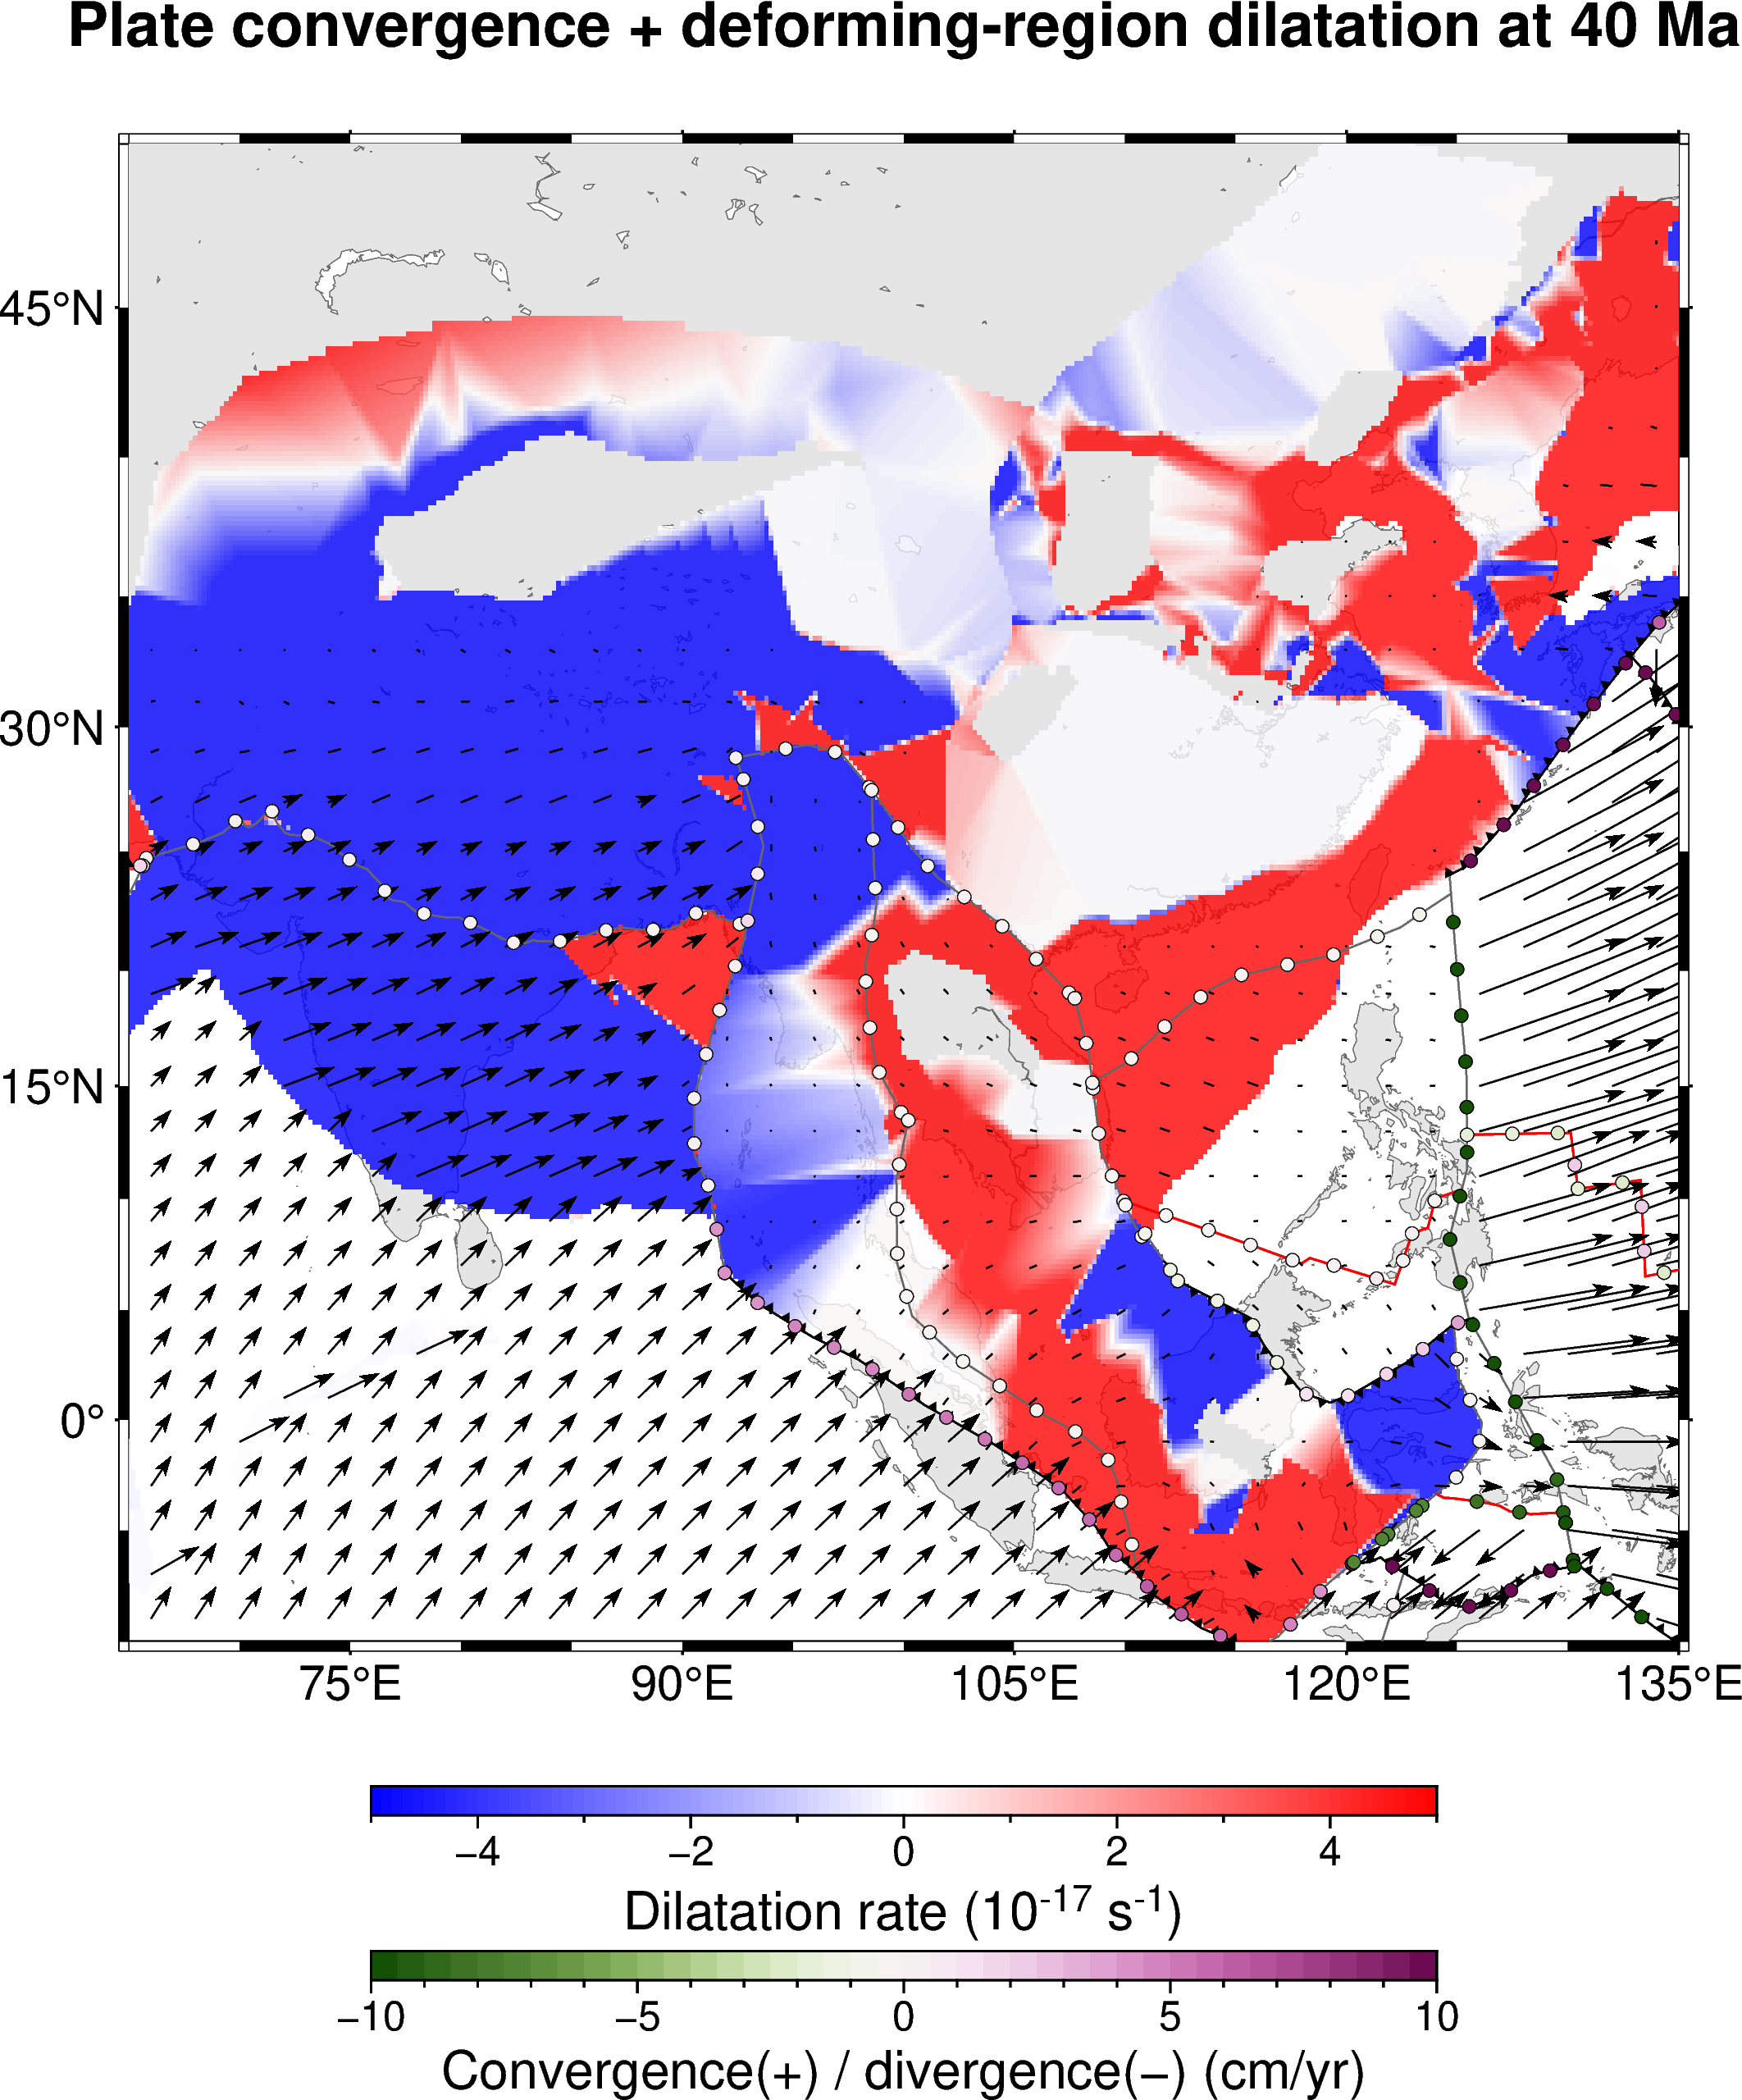


=== 20 Ma ===
  (skipping network #11: Triangulation is invalid)
  (skipping network #15: Triangulation is invalid)
  (skipping network #24: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #33: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #53: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #54: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #57: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  arrows @ 20 Ma: 1050 grid points, 756 above 0.1 cm/yr (max 10.12 cm/yr)
saved outputs/T14_paleo_strain_rate_020Ma.png


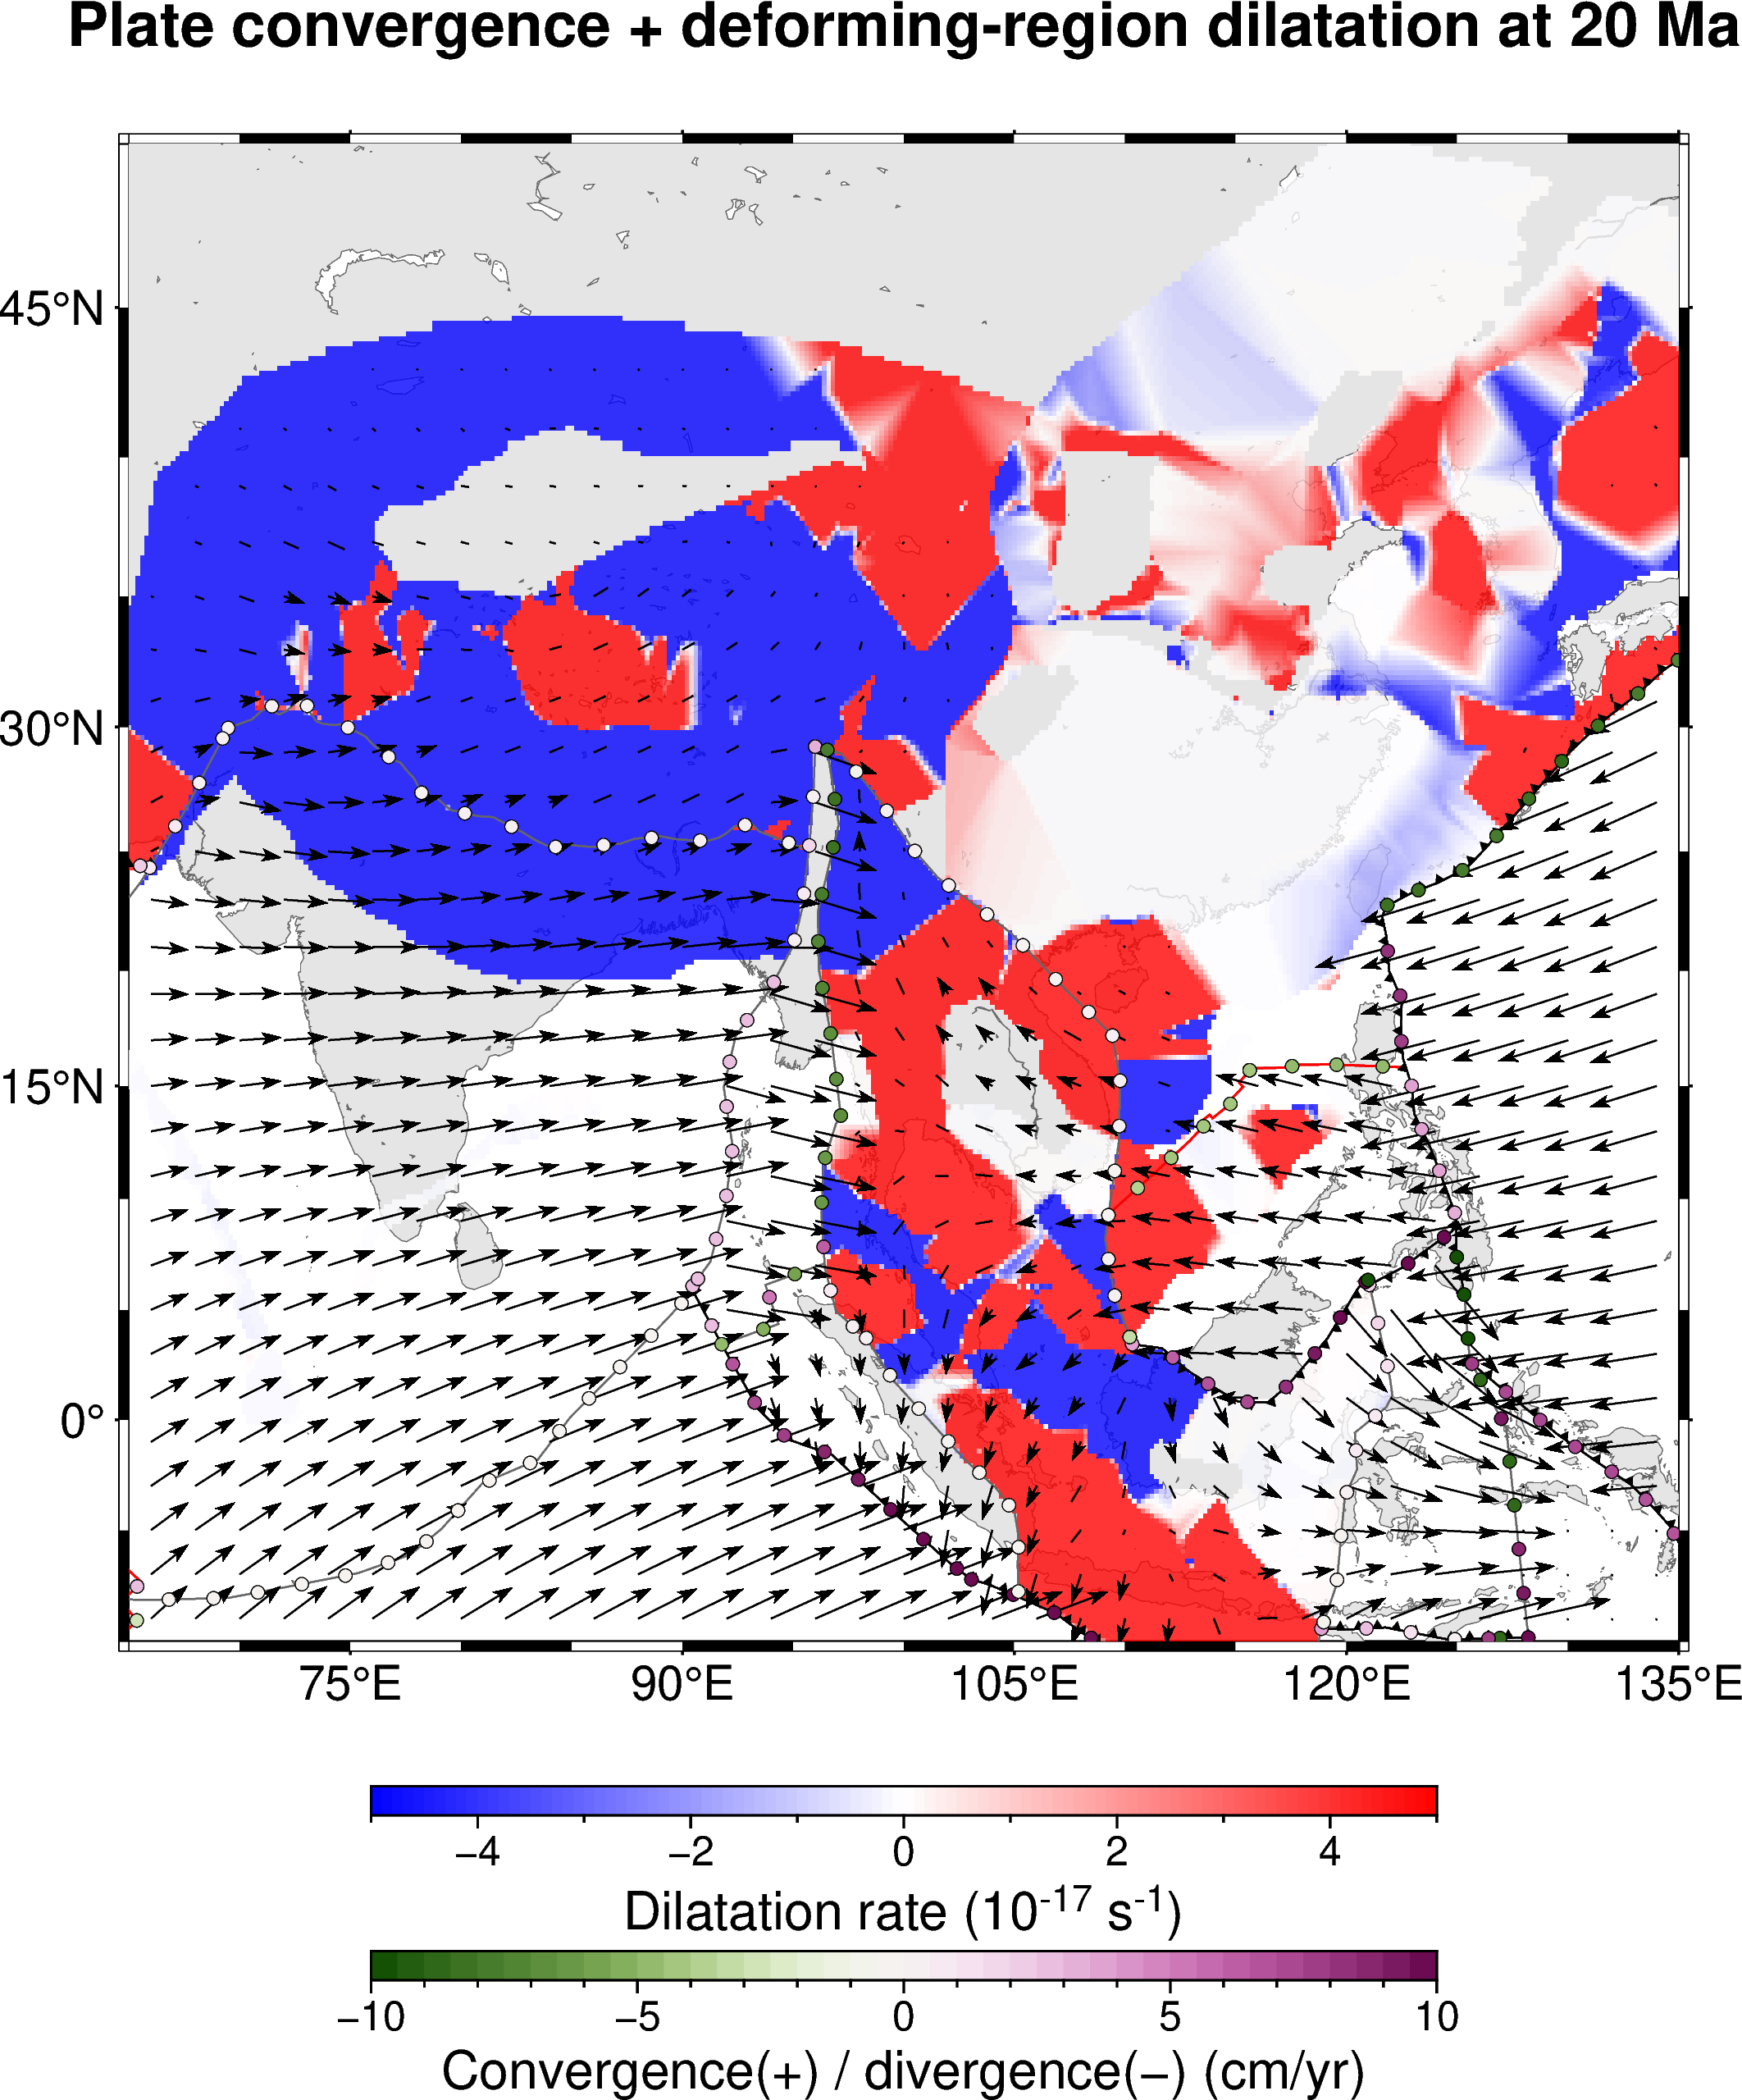


=== 0 Ma ===
  (skipping network #9: Triangulation is invalid)
  (skipping network #10: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #11: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #15: Triangulation is invalid)
  (skipping network #24: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #40: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  (skipping network #63: spans the dateline — matplotlib triangulation cannot represent it in 2-D)
  arrows @ 0 Ma: 1050 grid points, 628 above 0.1 cm/yr (max 7.92 cm/yr)
saved outputs/T14_paleo_strain_rate_000Ma.png


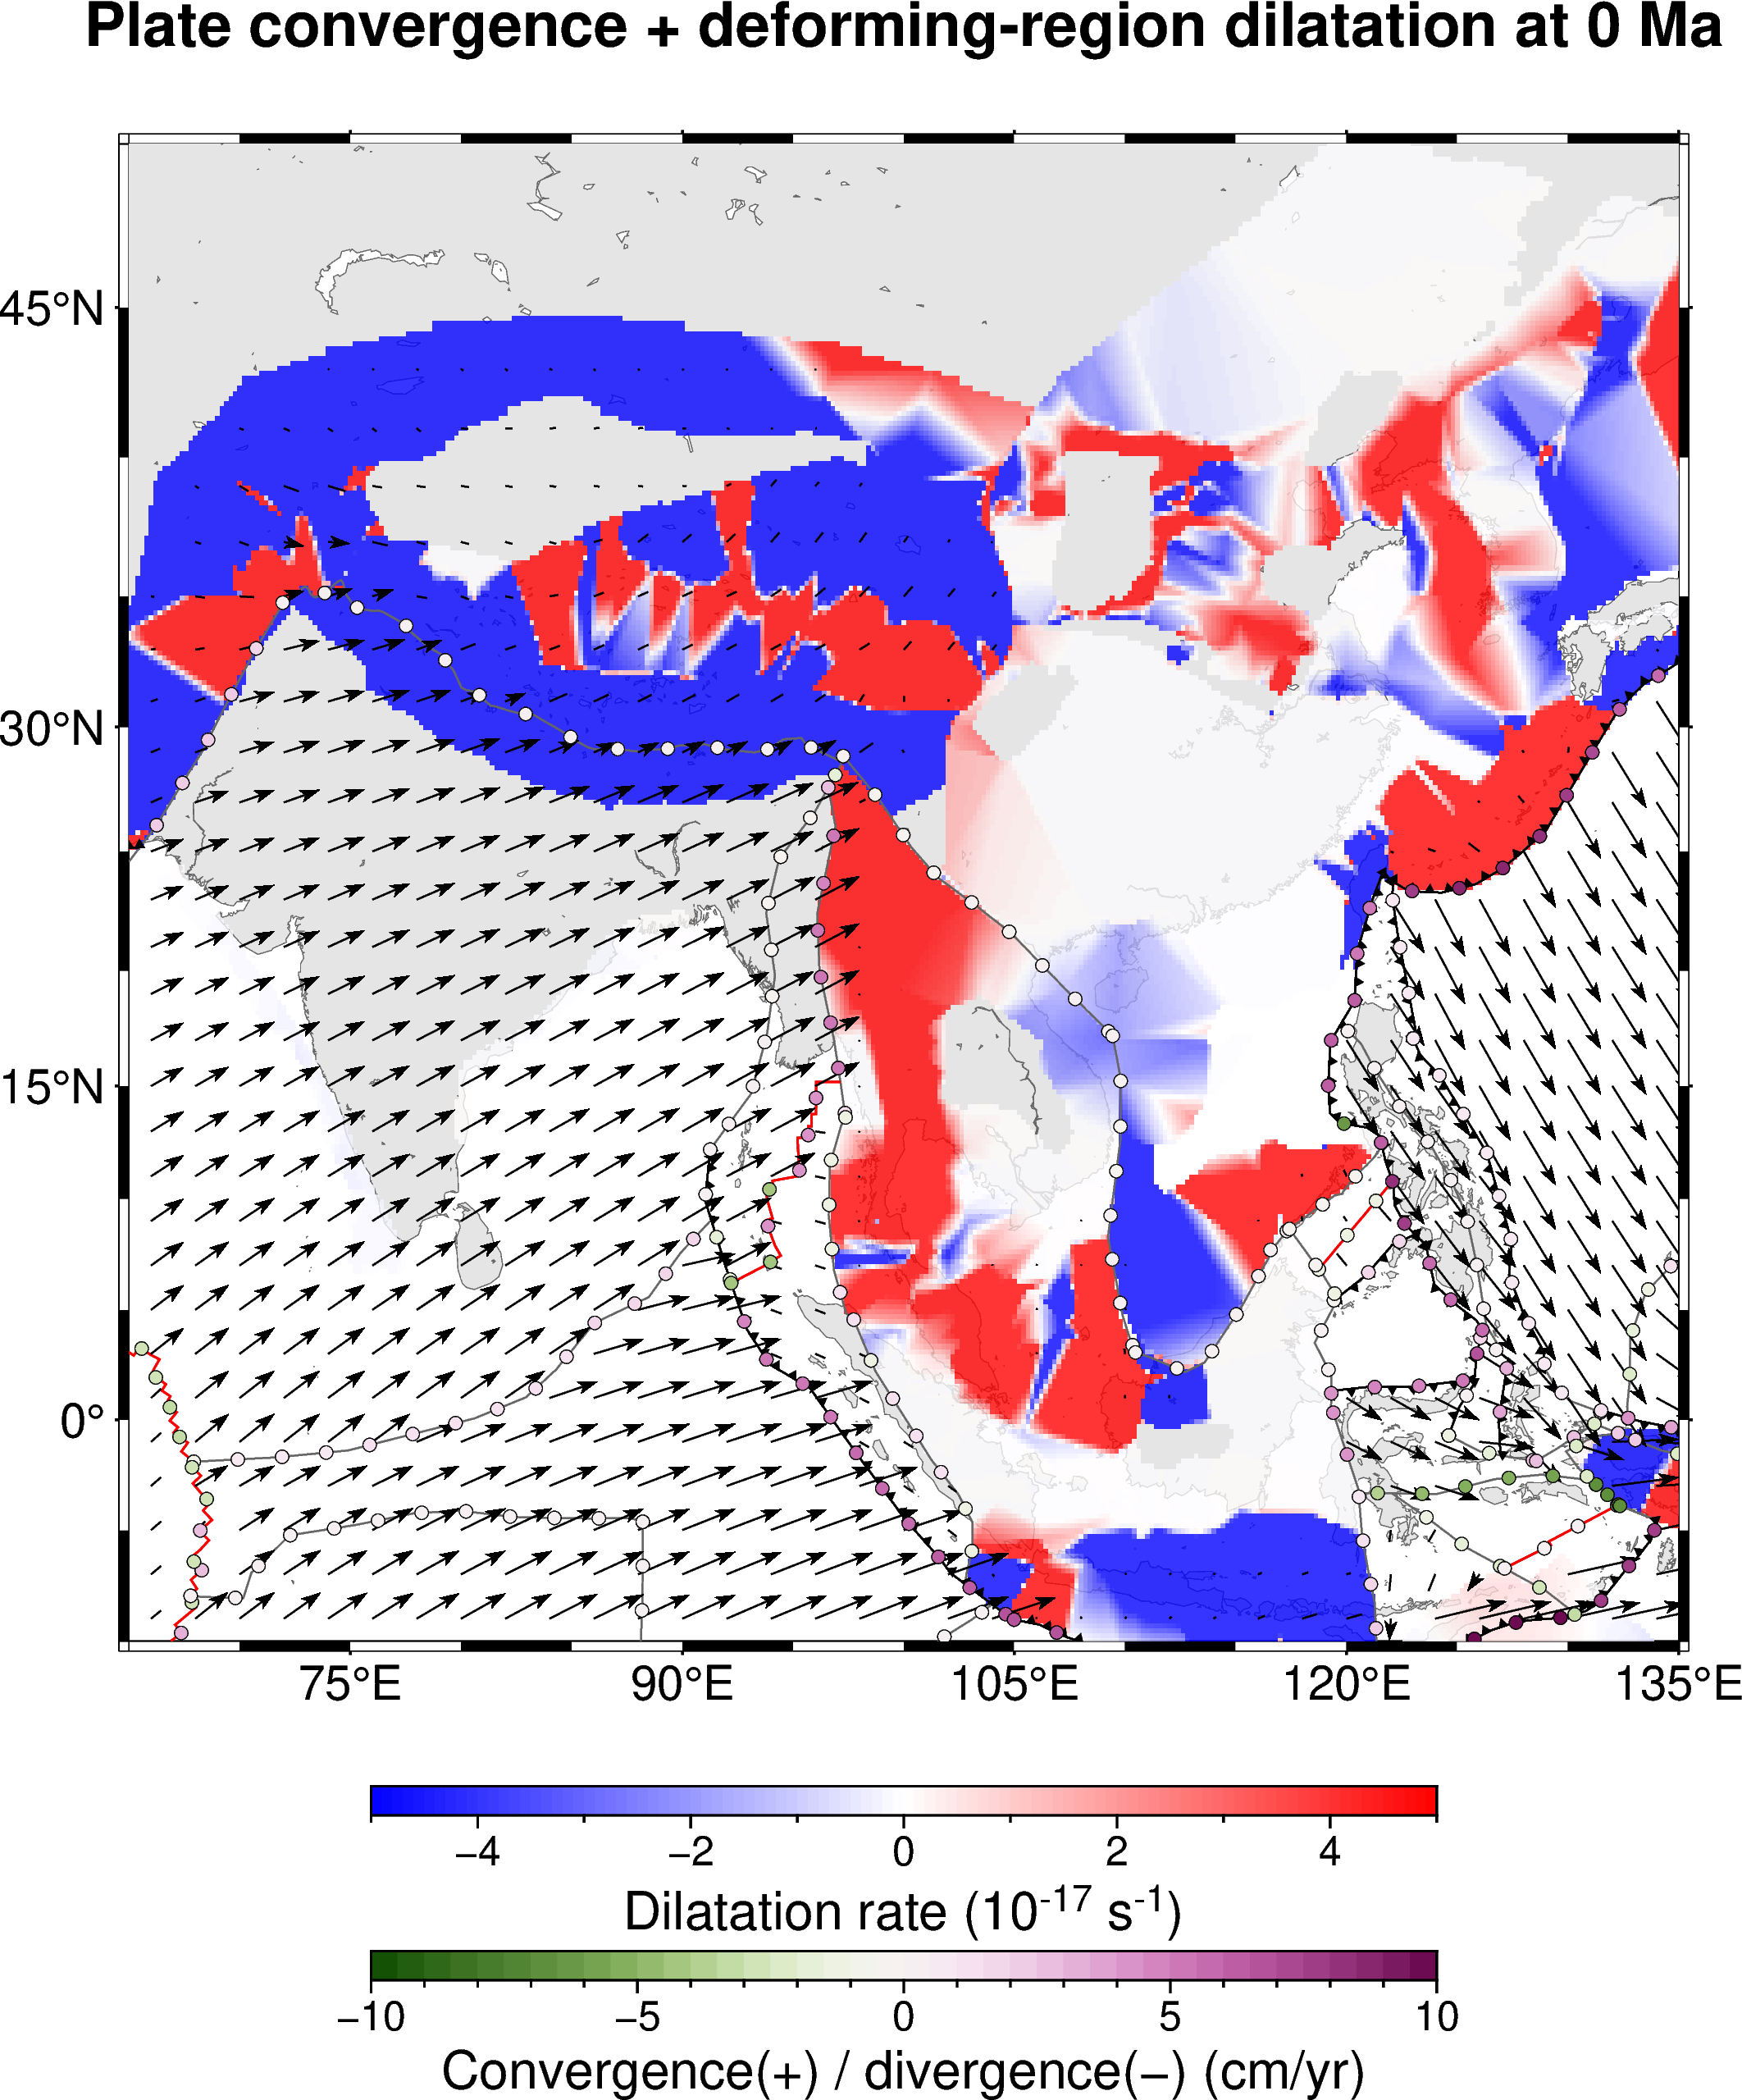

In [7]:
# Cell 6 — render at 40, 20, 0 Ma
INDO_AUS_REGION = (65, 135, -10, 50)   # (W, E, S, N)
for t in (40, 20, 0):
    print(f'\n=== {t} Ma ===')
    render_snapshot(t, INDO_AUS_REGION)

## What the three snapshots tell us

Dilatation (colour) and absolute velocity (arrows) are two different views of the same underlying kinematics. Dilatation is the divergence of the velocity field — high where the field is fanning out, low where it is converging. The two layers together let you check internal consistency (e.g. arrows fanning out should coincide with red dilatation) and read the *mechanism* of regional deformation (where is it convergence-driven vs. lateral-escape-driven?).

Anchoring on Eurasia (plate 301) makes block-relative motion legible — a Tibetan vertex's eastward escape arrow reads at its tectonically-meaningful ≈3 cm/yr rather than at the ≈10 cm/yr hotspot-frame absolute motion.

## Extend this

- **Other regions.** Swap `INDO_AUS_REGION` for the Andes `(-95, -55, -50, 15)`, the Mediterranean–Aegean–Anatolia `(0, 60, 25, 55)`, or Cascadia `(-135, -110, 35, 55)`. Reuse `render_snapshot` with no other changes.
- **Animation.** Loop `for t in range(40, -1, -1):` and save each figure with `fig.savefig(f'frame_{t:03d}.png', dpi=300)`. Stitch with `ffmpeg` or `imageio` (see **T03**).
- **Other strain-rate invariants.** Replace `v.strain_rate.get_dilatation_rate()` with `.get_total_strain_rate()` (von-Mises-style second invariant) for an unsigned magnitude map, or with `.get_principal_strain_rates()` for shortening-axis orientations.
- **Combine with T15.** Drop the predicted σHmax bars from T15 on top of the dilatation grid here — high dilatation in the deforming region should correlate with σHmax oriented perpendicular to extensional axes (a quick visual check on the Stephan first-order model).
- **Plot velocity arrows instead of dots.** Pygplates already gives you the (east, north) components in the boundary statistics; pyGMT's `style='V<head_length>+e+a40'` will render them as vector arrows.

## References

- Mather, B.R., Müller, R.D., Zahirovic, S., Cannon, J., Chin, M., Ilano, L., Wright, N.M., Alfonso, C., Williams, S., Tetley, M. & Merdith, A. (2024). Deep time spatio-temporal data analysis using GPlately. *Geosci. Data J.* 11, 3-10. https://doi.org/10.1002/gdj3.185
- Müller, R.D., Cannon, J., Qin, X., Watson, R.J., Gurnis, M., Williams, S., Pfaffelmoser, T., Seton, M., Russell, S.H.J. & Zahirovic, S. (2018). GPlates: Building a virtual Earth through deep time. *Geochem. Geophys. Geosys.* 19, 2243-2261. https://doi.org/10.1029/2018GC007584
- Tian, D., Uieda, L., Leong, W.J., Fröhlich, Y., Schlitzer, W., Grund, M., Jones, M., Toney, L., Yao, J., Magen, Y., Materna, K., Belem, A., Newton, T., Anant, A., Ziebarth, M., Quinn, J., Wessel, P. (2024). PyGMT: A Python interface for the Generic Mapping Tools. *Zenodo*. https://doi.org/10.5281/zenodo.13679085
- Wessel, P., Luis, J.F., Uieda, L., Scharroo, R., Wobbe, F., Smith, W.H.F. & Tian, D. (2019). The Generic Mapping Tools version 6. *Geochem. Geophys. Geosys.* 20, 5556-5564. https://doi.org/10.1029/2019GC008515
- Chin, M., Mather, B.R. & Müller, R.D. (2024). Plate Model Manager: A Python package for downloading and managing published plate-reconstruction models. *Zenodo*. https://github.com/michaelchin/plate-model-manager
- Zahirovic, S., Eleish, A., Doss, S., Pall, J., Cannon, J., Pistone, M., Tetley, M.G., Young, A. & Müller, R.D. (2022). Subduction and carbonate platform interactions. *Geoscience Data Journal* 9, 371-383. https://doi.org/10.1002/gdj3.146
- Müller, R.D., Flament, N., Cannon, J., Tetley, M.G., Williams, S.E., Cao, X., Bodur, Ö.F., Zahirovic, S. & Merdith, A. (2022). A tectonic-rules-based mantle reference frame since 1 billion years ago. *Solid Earth* 13, 1127-1159. https://doi.org/10.5194/se-13-1127-2022